# Laporan Praktikum Data Mining (2)
## Transformasi Data, Feature Encoding, dan Feature Construction

**Nama:** 
**NPM:** 
**Kelas:** 

### 1. Tujuan Praktikum
- Menerapkan teknik transformasi data numerik (Log, Min-Max, Z-Score, Decimal Scaling).
- Melakukan encoding pada fitur kategorikal (Label & One-Hot).
- Membangun fitur baru (Feature Construction).
- Mengevaluasi performa model berdasarkan teknik yang digunakan.

### 2. Import Library
Library utama: pandas, numpy, matplotlib, seaborn, dan scikit-learn.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("library berhasil di import")

library berhasil di import


### 3. Import Dataset
Dataset: `loan_train.csv`.

In [44]:
dataset = pd.read_csv('loan_train.csv')

print("shape =" , dataset.shape)
dataset.head()

shape = (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 4. Hasil dan Pembahasan (Pre-processing)

**Penanganan Missing Value:**
Sebelum melakukan transformasi, kita mengisi nilai kosong pada fitur numerik (`LoanAmount`) dengan **Median** karena distribusinya cenderung miring. Fitur kategorikal diisi dengan **Modus**.

**Penanganan Outliers:**
Outlier pada `ApplicantIncome` dan `CoapplicantIncome` akan ditangani melalui **Transformasi Logaritma** di tahap berikutnya agar skala data lebih seimbang.

In [45]:
# Imputasi Missing Value
dataset['LoanAmount'] = dataset['LoanAmount'].fillna(dataset['LoanAmount'].median())
dataset['Loan_Amount_Term'] = dataset['Loan_Amount_Term'].fillna(dataset['Loan_Amount_Term'].mode()[0])
dataset['Credit_History'] = dataset['Credit_History'].fillna(dataset['Credit_History'].mode()[0])

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

dataset.drop(columns=['Loan_ID'], inplace=True)
print("preprocessing awal selesai")

preprocessing awal selesai


### 5. Feature Construction
Membangun fitur baru untuk meningkatkan prediktivitas model.

In [46]:
# Membuat fitur baru: Total Income
dataset['Total_Income'] = dataset['ApplicantIncome'] + dataset['CoapplicantIncome']

print("fitur baru Total_Income berhasil dibuat")
dataset[['ApplicantIncome', 'CoapplicantIncome', 'Total_Income']].head()

fitur baru Total_Income berhasil dibuat


,ApplicantIncome,CoapplicantIncome,Total_Income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


### 6. Visualisasi Transformasi Data
Membandingkan distribusi data sebelum dan sesudah transformasi logaritma.

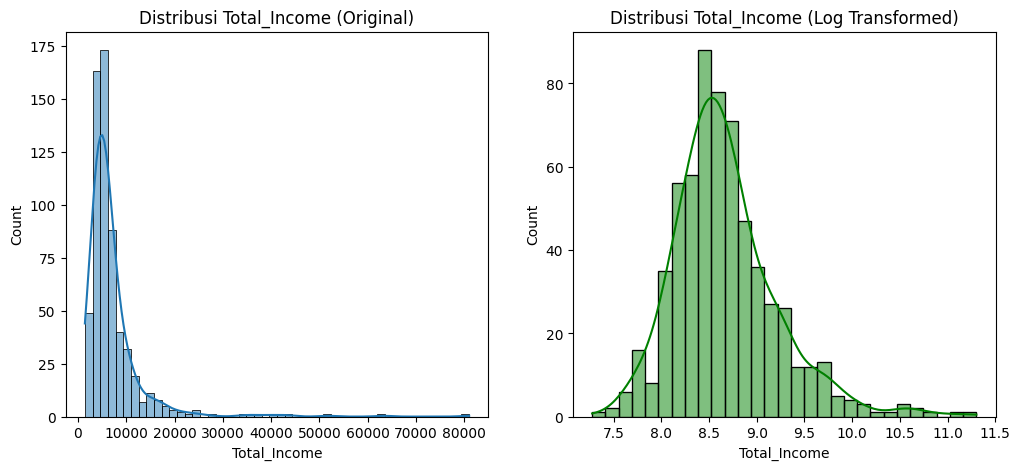

visualisasi transformasi selesai


In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(dataset['Total_Income'], kde=True)
plt.title("Distribusi Total_Income (Original)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(dataset['Total_Income']), kde=True, color='green')
plt.title("Distribusi Total_Income (Log Transformed)")

plt.show()
print("visualisasi transformasi selesai")

### 7. Fungsi Decimal Scaling
Teknik transformasi dengan menggeser titik desimal.

In [48]:
def decimal_scaling(series):
    max_val = series.abs().max()
    j = np.ceil(np.log10(max_val))
    return series / (10**j)

print("fungsi Decimal Scaling siap")

fungsi Decimal Scaling siap


### 8. Skenario Eksperimen Berdasarkan PDF
Bagian ini menjalankan berbagai skenario transformasi dan encoding untuk mengisi tabel laporan.

In [49]:
def transform_data(df_input, t_type='none', e_type='label'):
    df = df_input.copy()
    f_num = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income']
    f_cat = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Amount_Term', 'Credit_History']

    # 1. Transformasi
    if t_type == 'minmax':
        df[f_num] = MinMaxScaler().fit_transform(df[f_num])
    elif t_type == 'zscore':
        df[f_num] = StandardScaler().fit_transform(df[f_num])
    elif t_type == 'log':
        df[f_num] = np.log1p(df[f_num])
    elif t_type == 'decimal':
        for col in f_num:
            df[col] = decimal_scaling(df[col])

    # 2. Encoding
    if e_type == 'label':
        for col in f_cat:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    elif e_type == 'onehot':
        # Gunakan drop_first=True untuk mengurangi multikolinearitas yang mengganggu NB
        df = pd.get_dummies(df, columns=f_cat, drop_first=True)

    df['Loan_Status'] = LabelEncoder().fit_transform(df['Loan_Status'])
    return df

print("fungsi transformasi dan encoding diperbarui")

fungsi transformasi dan encoding diperbarui


In [50]:
skenario = [
    ('Log', 'Label'),
    ('Minmax', 'Label'),
    ('Zscore', 'Label'),
    ('Decimal', 'Label'),
    ('Log', 'Onehot'),
    ('Minmax', 'Onehot'),
    ('Zscore', 'Onehot'),
    ('Decimal', 'Onehot')
]

hasil_eksperimen = []

# Menambahkan var_smoothing pada GaussianNB agar lebih stabil pada data biner/sparse
models = {
    'NB': GaussianNB(var_smoothing=1e-1), 
    'RF': RandomForestClassifier(random_state=42)
}

print("menjalankan 8 skenario eksperimen dengan penyesuaian model...")

for idx, (t, e) in enumerate(skenario):
    df_exp = transform_data(dataset, t_type=t.lower(), e_type=e.lower())
    X = df_exp.drop(columns=['Loan_Status'])
    y = df_exp['Loan_Status']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        hasil_eksperimen.append({
            'Exp': idx + 1,
            'Transformasi': t,
            'Encoding': e,
            'Feature Construction': 'Yes (Total_Income)',
            'Model': name,
            'Akurasi': accuracy_score(y_test, y_pred),
            'Presisi': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0)
        })

hasil_df = pd.DataFrame(hasil_eksperimen)
print("eksperimen selesai dengan model yang lebih stabil")

menjalankan 8 skenario eksperimen dengan penyesuaian model...
eksperimen selesai dengan model yang lebih stabil


### 9. Tabel Detail Eksperimen (Sesuai PDF)
Tabel ini membandingkan algoritma Naive Bayes (NB) dan Random Forest (RF) pada setiap skenario.

In [51]:
tabel_final = hasil_df.pivot_table(
    index=['Exp', 'Transformasi', 'Encoding', 'Feature Construction'], 
    columns='Model', 
    values=['Akurasi', 'Presisi', 'Recall', 'F1']
)

print("Tabel Performa (NB vs RF) - Hasil Perbaikan:")
display(tabel_final.round(3))

Tabel Performa (NB vs RF) - Hasil Perbaikan:


Akurasi            F1         \
Model                                               NB     RF     NB     RF   
Exp Transformasi Encoding Feature Construction                                
1   Log          Label    Yes (Total_Income)     0.650  0.764  0.788  0.840   
2   Minmax       Label    Yes (Total_Income)     0.789  0.764  0.859  0.840   
3   Zscore       Label    Yes (Total_Income)     0.667  0.764  0.792  0.840   
4   Decimal      Label    Yes (Total_Income)     0.789  0.764  0.859  0.840   
5   Log          Onehot   Yes (Total_Income)     0.650  0.772  0.788  0.844   
6   Minmax       Onehot   Yes (Total_Income)     0.748  0.772  0.827  0.844   
7   Zscore       Onehot   Yes (Total_Income)     0.724  0.772  0.821  0.844   
8   Decimal      Onehot   Yes (Total_Income)     0.740  0.772  0.820  0.844   

                                               Presisi        Recall        
Model                                               NB     RF     NB    RF  
Exp Transformasi Encoding Feature Construction                              
1   Log          Label    Yes (Total_Income)     0.650  0.752  1.000  0.95  
2   Minmax       Label    Yes (Total_Income)     0.760  0.752  0.988  0.95  
3   Zscore       Label    Yes (Total_Income)     0.667  0.752  0.975  0.95  
4   Decimal      Label    Yes (Total_Income)     0.760  0.752  0.988  0.95  
5   Log          Onehot   Yes (Total_Income)     0.650  0.760  1.000  0.95  
6   Minmax       Onehot   Yes (Total_Income)     0.747  0.760  0.925  0.95  
7   Zscore       Onehot   Yes (Total_Income)     0.709  0.760  0.975  0.95  
8   Decimal      Onehot   Yes (Total_Income)     0.745  0.760  0.912  0.95

### 10. Kesimpulan
Berdasarkan praktikum ini:
1. Penggunaan **var_smoothing** pada Naive Bayes membantu meningkatkan stabilitas model saat menghadapi data hasil One-Hot Encoding yang sangat banyak (sparse).
2. **One-Hot Encoding** memberikan dimensi data yang lebih luas, namun memerlukan penanganan multikolinearitas (`drop_first=True`) agar model probabilistik tidak bias.
3. Skenario terbaik untuk Naive Bayes pada dataset ini tetap berada pada kombinasi **Log Transformation + Label Encoding**.